## Exploratory Data Analysis

#### Import packages

In [307]:
import pandas as pd 
import plotly as py 
import seaborn as sns
from pathlib import Path
import plotly.express as px
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

### Read in and merge data

In [308]:
# Pull data file in from data folder 

data_dir = Path("../data")
file_path = data_dir / "survivoR.xlsx"

#### Castaway overview and results data

In [309]:
# Read in Castaway Overview data and view a few rows

castaways = pd.read_excel(file_path, sheet_name="Castaways")

castaways.head()

,version,version_season,season,full_name,castaway_id,castaway,age,city,state,episode,...,jury,finalist,winner,acknowledge,ack_look,ack_speak,ack_gesture,ack_smile,ack_quote,ack_score
0,US,US50,50,Jenna Lewis-Dougherty,US0009,Jenna,47,Woodland,California,1,...,False,False,False,NaN,1.0,1.0,1.0,1.0,NaN,4.0
1,US,US50,50,Kyle Fraser,US0726,Kyle,31,Brooklyn,New York,1,...,False,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,US,US50,50,Savannah Louie,US0747,Savannah,31,Atlanta,Georgia,2,...,False,False,False,NaN,0.0,0.0,0.0,0.0,NaN,0.0
3,US,US50,50,Q Burdette,US0691,Q,31,Germantown,Tennessee,3,...,False,False,False,NaN,0.0,0.0,1.0,0.0,NaN,1.0
4,US,US50,50,Mike White,US0555,Mike,54,Hanalei,Hawaii,4,...,False,False,False,NaN,1.0,1.0,1.0,1.0,"Ciao, guys. See ya, man.",4.0


In [310]:
# View list of columns

print(list(castaways.columns))

['version', 'version_season', 'season', 'full_name', 'castaway_id', 'castaway', 'age', 'city', 'state', 'episode', 'day', 'order', 'result', 'jury_status', 'place', 'original_tribe', 'jury', 'finalist', 'winner', 'acknowledge', 'ack_look', 'ack_speak', 'ack_gesture', 'ack_smile', 'ack_quote', 'ack_score']


In [311]:
# Keep potential variables of interest for modeling

castaways_vars_keep = ['version', 'season', 'full_name', 'castaway_id', 'age', 'city', 'state', 'order', 'place', 'jury', 'finalist', 'winner']
castaways = castaways[castaways_vars_keep]
castaways.head()

,version,season,full_name,castaway_id,age,city,state,order,place,jury,finalist,winner
0,US,50,Jenna Lewis-Dougherty,US0009,47,Woodland,California,1,24,False,False,False
1,US,50,Kyle Fraser,US0726,31,Brooklyn,New York,2,23,False,False,False
2,US,50,Savannah Louie,US0747,31,Atlanta,Georgia,3,22,False,False,False
3,US,50,Q Burdette,US0691,31,Germantown,Tennessee,4,21,False,False,False
4,US,50,Mike White,US0555,54,Hanalei,Hawaii,5,20,False,False,False


In [312]:
# Check number of rows and columns
castaways.shape

(1441, 12)

#### Castaway details data

In [313]:
# Read in Castaway Details data and view a few rows 

details = pd.read_excel(file_path, sheet_name="Castaway Details")

details.head()


,castaway_id,full_name,full_name_detailed,castaway,last_name,date_of_birth,date_of_death,gender,african,asian,...,bipoc,lgbt,personality_type,occupation,collar,three_words,hobbies,pet_peeves,race,ethnicity
0,US0001,Sonja Christopher,Sonja Christopher,Sonja,Christopher,1937-01-28,2024-04-26,Female,0.0,0.0,...,0.0,1.0,ENFP,Musician,No collar,NaN,NaN,NaN,NaN,NaN
1,US0002,B.B. Andersen,B.B. Andersen,B.B.,Andersen,1936-01-18,2013-10-29,Male,0.0,0.0,...,0.0,0.0,ESTJ,Real Estate Developer,White collar,NaN,NaN,NaN,NaN,NaN
2,US0003,Stacey Stillman,Stacey Stillman,Stacey,Stillman,1972-08-11,NaT,Female,0.0,0.0,...,0.0,0.0,ENTJ,Attorney,White collar,NaN,NaN,NaN,NaN,NaN
3,US0004,Ramona Gray,Ramona Gray,Ramona,Gray,1971-01-20,NaT,Female,1.0,0.0,...,1.0,0.0,ISTJ,Biochemist/Chemist,White collar,NaN,NaN,NaN,Black,NaN
4,US0005,Dirk Been,Dirk Been,Dirk,Been,1976-06-15,NaT,Male,0.0,0.0,...,0.0,0.0,ISFP,Dairy Farmer,Blue collar,NaN,NaN,NaN,NaN,NaN


In [314]:
# Check number of rows and columns
details.shape

(1200, 22)

In [315]:
# Print list of columns 

print(list(details.columns))

['castaway_id', 'full_name', 'full_name_detailed', 'castaway', 'last_name', 'date_of_birth', 'date_of_death', 'gender', 'african', 'asian', 'latin_american', 'native_american', 'bipoc', 'lgbt', 'personality_type', 'occupation', 'collar', 'three_words', 'hobbies', 'pet_peeves', 'race', 'ethnicity']


In [316]:
# Keep potential variables of interest for modeling

details_vars_keep = ['castaway_id', 'gender', 'occupation', 'bipoc', 'african', 'asian', 'latin_american', 'native_american', 'race', 'ethnicity']

details = details[details_vars_keep]

details.head()

,castaway_id,gender,occupation,bipoc,african,asian,latin_american,native_american,race,ethnicity
0,US0001,Female,Musician,0.0,0.0,0.0,0.0,0.0,NaN,NaN
1,US0002,Male,Real Estate Developer,0.0,0.0,0.0,0.0,0.0,NaN,NaN
2,US0003,Female,Attorney,0.0,0.0,0.0,0.0,0.0,NaN,NaN
3,US0004,Female,Biochemist/Chemist,1.0,1.0,0.0,0.0,0.0,Black,NaN
4,US0005,Male,Dairy Farmer,0.0,0.0,0.0,0.0,0.0,NaN,NaN


In [317]:
# Merge data frames
# Left join to preserve full list of castaways, because it has more rows than details 

df = pd.merge(castaways, details, on="castaway_id", how="left")

In [318]:
# View rows of merged df
df.head()

,version,season,full_name,castaway_id,age,city,state,order,place,jury,...,winner,gender,occupation,bipoc,african,asian,latin_american,native_american,race,ethnicity
0,US,50,Jenna Lewis-Dougherty,US0009,47,Woodland,California,1,24,False,...,False,Female,Student,0.0,0.0,0.0,0.0,0.0,NaN,NaN
1,US,50,Kyle Fraser,US0726,31,Brooklyn,New York,2,23,False,...,False,Male,Attorney,1.0,1.0,0.0,0.0,0.0,NaN,NaN
2,US,50,Savannah Louie,US0747,31,Atlanta,Georgia,3,22,False,...,False,Female,Former Reporter,1.0,0.0,1.0,0.0,0.0,NaN,NaN
3,US,50,Q Burdette,US0691,31,Germantown,Tennessee,4,21,False,...,False,Male,Real Estate Agent,1.0,1.0,0.0,0.0,0.0,NaN,NaN
4,US,50,Mike White,US0555,54,Hanalei,Hawaii,5,20,False,...,False,Male,Filmmaker,0.0,0.0,0.0,0.0,0.0,NaN,NaN


In [319]:
# View shape of merged df
df.shape

(1441, 21)

### Cleaning and visualizing data

#### Version (country) of show

I choose to limit the dataset to US seasons of the show. Every version of the show is fairly unique and predictors may influence outcomes differently, and I am interested in predicting player outcomes in the US version of the show specifically. 

In [320]:
# Summarize versions of show in df

print(df["version"].value_counts())


version
US    917
AU    278
SA    166
UK     46
NZ     34
Name: count, dtype: int64


In [321]:
# Limit to US seasons of the show

df = df[df["version"]=="US"]
print(df["version"].value_counts())

version
US    917
Name: count, dtype: int64


#### Count of players per season

In [322]:
# Visualize distribution of players/rows across US seasons in df

# Get counts sorted by season
season_counts = df["season"].value_counts().sort_index().reset_index()
season_counts.columns = ["season", "count"]

# Create bar chart
fig = px.bar(
    season_counts,
    x="season",
    y="count",
    title="Count of Players per Season",
    labels={"season": "Season", "count": "Number of Players"},
)

fig.show()

This distribution is accurate based on my knowledge of the show. Most seasons hover around 18 players, with some having more and some less, and the most recent Season 50 had the most players ever at 24. The data appears complete and thus observations are distributed fairly evenly across seasons. However, because the number of players varies between seasons, I will transform the outcome metric of placement to be relative to the total players in a given season. 

#### Unique vs. total players

In [323]:
# count total players
total_players = df.shape[0]

# count unique players
unique_players = df['castaway_id'].nunique()

print(f'Total players in data: {total_players}')
print(f'Unique players in data: {unique_players}')

Total players in data: 917
Unique players in data: 751


Example returning (duplicate) players

In [324]:
# identify players who play in more than one season
player_dupes = df[df.duplicated(subset=['castaway_id'], keep=False)]

# view some rows of returning players 
print(player_dupes.sort_values(by='castaway_id').head(10))

    version  season              full_name castaway_id  age            city  \
0        US      50  Jenna Lewis-Dougherty      US0009   47        Woodland   
909      US       1            Jenna Lewis      US0009   22        Franklin   
802      US       8            Jenna Lewis      US0009   26         Burbank   
910      US       1       Gervase Peterson      US0010   30     Willingboro   
451      US      27       Gervase Peterson      US0010   43    Philadelphia   
913      US       1             Susan Hawk      US0013   38         Palmyra   
792      US       8             Susan Hawk      US0013   42       Las Vegas   
914      US       1            Rudy Boesch      US0014   72  Virginia Beach   
788      US       8            Rudy Boesch      US0014   75  Virginia Beach   
369      US      31      Kelly Wiglesworth      US0015   37      Greensboro   

              state  order  place   jury  ...  winner  gender  \
0        California      1     24  False  ...   False  Female   


I will keep returning players in the dataset and not de-dupe per castaway_id, so each row in the data will be one player performance in a given season. Players who play several times may perform different each time, and other predictors may change (e.g. age). Including each appearance with its predictors and performance outcome will fully capture the available data for modeling.

### Feature engineering

#### Standardize regression outcome variable (placement)

In [325]:
# Visualize distribution of player placements

# Get counts sorted by placement 
season_counts = df["place"].value_counts().sort_index().reset_index()
season_counts.columns = ["place", "count"]

# Create bar chart
fig = px.bar(
    season_counts,
    x="place",
    y="count",
    title="Count of Player Placements Across Seasons",
    labels={"place": "Place", "count": "Number of Players"},
)

fig.show()

Some seasons have more castaways and therefore a larger number of placements they can fall into to reflect their performance in the game (and the outcome metric here). To standardize this across seasons, I will transform the outcome variable into a placement score to measure the player's placement relative to the total players in their season, rather than their raw placement number. 

In [326]:
# calculate cast size
df['cast_size'] = df.groupby('season')['castaway_id'].transform('count')

# create placement score metric of placement relative to cast size 
df["place_score"] = (df["cast_size"] - df["place"] + 1) / df["cast_size"]

In [327]:
df.head()

,version,season,full_name,castaway_id,age,city,state,order,place,jury,...,occupation,bipoc,african,asian,latin_american,native_american,race,ethnicity,cast_size,place_score
0,US,50,Jenna Lewis-Dougherty,US0009,47,Woodland,California,1,24,False,...,Student,0.0,0.0,0.0,0.0,0.0,NaN,NaN,24,0.041667
1,US,50,Kyle Fraser,US0726,31,Brooklyn,New York,2,23,False,...,Attorney,1.0,1.0,0.0,0.0,0.0,NaN,NaN,24,0.083333
2,US,50,Savannah Louie,US0747,31,Atlanta,Georgia,3,22,False,...,Former Reporter,1.0,0.0,1.0,0.0,0.0,NaN,NaN,24,0.125000
3,US,50,Q Burdette,US0691,31,Germantown,Tennessee,4,21,False,...,Real Estate Agent,1.0,1.0,0.0,0.0,0.0,NaN,NaN,24,0.166667
4,US,50,Mike White,US0555,54,Hanalei,Hawaii,5,20,False,...,Filmmaker,0.0,0.0,0.0,0.0,0.0,NaN,NaN,24,0.208333


#### Create classification outcome variable  

In [328]:
# create binary variable for whether player "made the merge"

df['made_merge'] = ((df['jury'] == 1) | (df['finalist'] == 1)).astype(int)

In [329]:
df['made_merge'].value_counts()

made_merge
1    556
0    361
Name: count, dtype: int64

Not perfect match for merge (sometimes one person makes merge but not jury) but close enough approximation with data I have. This breakdown seems accurate to me. 61%/39% split means class imbalance isn't a big issue.

#### Center age relative to rest of season's cast

In [330]:
df['rel_age'] = df['age'] - df.groupby('season')['age'].transform('mean')

I transform the age variable to instead use age relative to the rest of that season's cast. I think a contestant's age relative to their own cast is more likely to be predictive of their placement than their absolute age. I think a 50 year old contestant on a season where the average age is 40 is likely to perform better than a 50 year old contestant amongst an average age of 30, both in terms of their social fit with the rest of the group and their physical challenge performance relative to their peers. 

#### Group states into region categories

In [331]:
# Define mapping from states to Census regions
full_name_region_mapping = {
    # Northeast
    'Connecticut': 'Northeast', 'Maine': 'Northeast', 'Massachusetts': 'Northeast', 
    'New Hampshire': 'Northeast', 'Rhode Island': 'Northeast', 'Vermont': 'Northeast', 
    'New Jersey': 'Northeast', 'New York': 'Northeast', 'Pennsylvania': 'Northeast',
    
    # Midwest
    'Illinois': 'Midwest', 'Indiana': 'Midwest', 'Michigan': 'Midwest', 
    'Ohio': 'Midwest', 'Wisconsin': 'Midwest', 'Iowa': 'Midwest', 
    'Kansas': 'Midwest', 'Minnesota': 'Midwest', 'Missouri': 'Midwest', 
    'Nebraska': 'Midwest', 'North Dakota': 'Midwest', 'South Dakota': 'Midwest',
    
    # South
    'Delaware': 'South', 'Florida': 'South', 'Georgia': 'South', 'Maryland': 'South', 
    'North Carolina': 'South', 'South Carolina': 'South', 'Virginia': 'South', 
    'District of Columbia': 'South', 'D.C.': 'South', 'West Virginia': 'South', 'Alabama': 'South', 
    'Kentucky': 'South', 'Mississippi': 'South', 'Tennessee': 'South', 
    'Arkansas': 'South', 'Louisiana': 'South', 'Oklahoma': 'South', 'Texas': 'South',
    
    # West
    'Arizona': 'West', 'Colorado': 'West', 'Idaho': 'West', 'Montana': 'West', 
    'Nevada': 'West', 'New Mexico': 'West', 'Utah': 'West', 'Wyoming': 'West', 
    'Alaska': 'West', 'California': 'West', 'Hawaii': 'West', 'Oregon': 'West', 'Washington': 'West'
}

def get_region_from_fullname(state):
    if pd.isna(state):
        return "Unknown/International"
    
    return full_name_region_mapping.get(state, "Unknown/International")

# Apply to df
df['region'] = df['state'].apply(get_region_from_fullname)

# Check count in each region
print(df['region'].value_counts())

region
West                     324
South                    276
Northeast                207
Midwest                   95
Unknown/International     15
Name: count, dtype: int64


In [332]:
df.shape

(917, 26)

#### Group occupations into categories

In [333]:
def categorize_occupation(job):
    if pd.isna(job):
        return "Other"
    
    job = str(job).lower()
    
    # Physical (athletes, tactical, protective services, fitness, labor/trades)
    if any(k in job for k in [
        'athlete', 'trainer', 'fire', 'police', 'cop', 'coach', 'fitness', 'body',
        'military', 'army', 'navy', 'marine', 'air force', 'guard', 'trooper', 
        'security', 'surfer', 'martial', 'fighter', 'olympian', 'pro ', 'stunt',
        'construction', 'mechanic', 'carpenter', 'plumber', 'electrician', 
        'contractor', 'farmer', 'fisherman', 'driver', 'pilot', 'laborer', 
        'welder', 'painter', 'landscape', 'worker', 'deckhand', 'inspector',
        'fisherman', 'veteran', 'paratrooper', 'sheriff', 'yogi', 'nfl', 'player', 'nba',
        'wellness', 'volleyball', 'racer', 'captain', 'paralympian', 'medalist', 'maintenance'
    ]):
        return "Physical"
        
    # Corporate (business, sales, finance, management, legal, real estate)
    elif any(k in job for k in [
        'exec', 'manager', 'sales', 'real estate', 'lawyer', 'consultant', 
        'finance', 'ceo', 'director', 'business', 'entrepreneur', 'banker', 
        'analyst', 'marketing', 'recruiter', 'accountant', 'insurance', 'broker', 
        'agent', 'executive', 'corporate', 'trader', 'investor', 'attorney',
        'legal', 'project', 'operations', 'strategist', 'fundraiser', 'judge',
        'politician'
    ]):
        return "Corporate"
        
    # Creative (media, writing, arts, entertainment, design)
    elif any(k in job for k in [
        'writer', 'actor', 'actress', 'model', 'artist', 'media', 'journalist', 'musician',
        'singer', 'dj', 'producer', 'host', 'dancer', 'blogger', 'influencer', 
        'photographer', 'author', 'comedian', 'designer', 'fashion', 'radio',
        'filmmaker', 'editor', 'podcaster', 'content', 'performer', 'magician',
        'reporter', 'youtube', 'commentator', 'star', 'gamer', 'videographer',
        'showgirl', 'miss', 'anchor', 'speaker'
    ]):
        return "Creative"
        
    # Academic (students, teachers, professors, researchers, education)
    elif any(k in job for k in [
        'student', 'teacher', 'professor', 'research', 'researcher', 'educator', 
        'principal', 'dean', 'academic', 'tutor', 'instructor', 'scholar',
        'kindergarten', 'coach', 'school', 'university', 'college', 'dean',
        'graduate', 'phd'
    ]):
        return "Academic"
        
    # Medical/STEM (healthcare, engineering, science, IT, technology)
    elif any(k in job for k in [
        'nurse', 'doctor', 'engineer', 'scientist', 'medical', 'dentist', 
        'surgeon', 'pharmacist', 'therapist', 'chemist', 'biologist', 'physics', 
        'vet', 'software', 'programmer', 'it ', 'tech', 'technician', 'analyst',
        'biochemist', 'pathologist', 'psychiatrist', 'psychologist', 'hygienist',
        'radiologic', 'paramedic', 'emt', 'medic', 'surgeon', 'developer', 'dietician',
        'dietitian', 'astronaut', 'physician'
    ]) or 'ologist' in job or 'olomist' in job:
        return "Medical/STEM"
        
    # Service/Hospitality/Relationships (food service, beauty, counseling, support, admin)
    elif any(k in job for k in [
        'bartender', 'server', 'flight attendant', 'host', 'service', 'waiter', 
        'hair', 'stylist', 'counselor', 'secretary', 'waitress', 'barista', 
        'hospitality', 'hotel', 'restaurant', 'caterer', 'nanny', 'social worker', 
        'minister', 'pastor', 'clergy', 'therapist', 'assistant', 'receptionist',
        'casino', 'dealer', 'prowler', 'flight', 'stewardess', 'concierge',
        'orphan', 'advocate', 'volunteer', 'community', 'nonprofit', 'charity',
        'coordinator', 'administrative', 'clerk', 'office', 'human resources', 'hr', 'owner', 
        'barber', 'cosmetologist', 'caretaker', 'guide', 'chef', 'promoter', 'vendor', 'planner',
        'mentor', 'homemaker', 'home', 'staff', 'mom'
    ]):
        return "Service/Hospitality"
        
    else:
        return "Other"

# Apply to dataframe
df['occupation_group'] = df['occupation'].apply(categorize_occupation)

# Check distribution across categories and other
print(df['occupation_group'].value_counts())

occupation_group
Corporate              243
Physical               199
Academic               121
Creative               115
Service/Hospitality    115
Medical/STEM            65
Other                   59
Name: count, dtype: int64


In [334]:
# Filter the data frame to show only rows where the occupation group is 'Other'
other_occupations = df[df['occupation_group'] == 'Other']['occupation'].unique()

# Print the list of unhandled occupation strings
print(f"Total unique 'Other' occupations: {len(other_occupations)}")
for job in sorted([str(j) for j in other_occupations]):
    print(job)

Total unique 'Other' occupations: 45
Actuary
Architect
Auto Customizer
Bellhop
Bookkeeper
Bounty Hunter
Cattle Rancher
Drill Sergeant
Expert Witness Locator
Fast Food Franchisee
Fishmonger
Freelance Marketer
Gardener
Goat Rancher
Gravedigger
Heart Valve Specialist
Hedge Fund Support
Jeweler
Lumberjill
Merchandiser
Miami Marlins President
Mortician
Motorcycle Repair
Oil Driller
Oil Tanker Crewman;Chemical Disposal
Pet Cremator
Pharmaceutical Representative
Phlebotomist
Political Science Ph.D.
Professional Wrestler
Rancher
Realtor
Residential Builder
Retail Buyer
Retired NYPD Detective
Roller Girl
Scout Troop Leader
Strategy Associate
Surgical Podiatrist
Tire Repair
Toymaker
Truck Assembler
U.S. Mail Carrier
Warehouse Associate
Zookeeper


#### Race and ethnicity

In [335]:
# Define the columns you want to analyze
race_cols = ['african', 'asian', 'latin_american', 'native_american']

# group by 'bipoc' and sum to get total count for each group
bipoc_race = df.groupby('bipoc')[race_cols].sum()

print("Breakdown by BIPOC Status") 
print(bipoc_race)


Breakdown by BIPOC Status
       african  asian  latin_american  native_american
bipoc                                                 
0.0        0.0    0.0             0.0              0.0
1.0      148.0   88.0            75.0              4.0


This table confirms that the binary BIPOC value in the data is 1 if the player falls into any of the minority race/ethnicity categories (African, Asian, Latin American, or Native American) and no if they do not (i.e. if they are white). Thus, BIPOC can be used as a binary race/ethnicity category that equals 1 if they are BIPOC and 0 if they are white. 

#### Gender

The current gender categories are male, female, and non-binary. There are 2 non-binary players out of 917 in the US version of the show. I also know from watching the show that these players both played the game as female, and so their pregame demographics and in-game identity categorized them as that gender. I will therefore assign these 2 players to that gender identify for the purposes of this modeling in order to create a binary gender variable that reflects how contestants played the game.  

In [336]:
# view counts by gender

gender_totals = df['gender'].value_counts()
print(gender_totals)

gender
Male          460
Female        455
Non-binary      2
Name: count, dtype: int64


In [337]:
# update gender for 2 non-binary players

df['gender'] = df['gender'].replace('Non-binary', 'Female')

gender_totals = df['gender'].value_counts()
print(gender_totals)

gender
Male      460
Female    457
Name: count, dtype: int64


In [338]:
# create numeric binary variable for gender 

# map male to 0 and female to 1
df['gender'] = df['gender'].map({'Male': 0, 'Female': 1})

# check to confirm values mapped correctly and see counts
print(df['gender'].value_counts(dropna=False))

gender
0    460
1    457
Name: count, dtype: int64


#### Season "Era"

Survivor's 50 seasons can be split into what is known as the "Old Era" and the "New Era", with the New Era starting in Season 41. The New Era seasons involve some changes to the game mechanics (e.g. a shorter, faster season and more in-game advantages and gimmicks) as well as the introduction of a CBS diversity mandate that required 50% of players on each season to be BIPOC. Based on my knowledge of the show, I believe these changes could mean that the demographic predictors I'm using had a differing effect on placement in the Old vs. New Era seasons, so I am adding a binary variable for New Era to account for how the season era interacts with the rest of the predictors in the modeling. 

In [339]:
# create binary variable for era 
df['new_era'] = (df['season'] >= 41).astype(int)

# check era values 
print(df[["season", "new_era"]].drop_duplicates().sort_values("season"))

     season  new_era
901       1        0
885       2        0
869       3        0
853       4        0
837       5        0
821       6        0
805       7        0
787       8        0
769       9        0
749      10        0
731      11        0
715      12        0
695      13        0
676      14        0
660      15        0
640      16        0
622      17        0
606      18        0
586      19        0
566      20        0
546      21        0
528      22        0
510      23        0
492      24        0
474      25        0
454      26        0
434      27        0
416      28        0
398      29        0
380      30        0
360      31        0
342      32        0
322      33        0
302      34        0
284      35        0
264      36        0
244      37        0
226      38        0
206      39        0
186      40        0
168      41        1
150      42        1
132      43        1
114      44        1
96       45        1
78       46        1
60       47  

In [340]:
df.head()

,version,season,full_name,castaway_id,age,city,state,order,place,jury,...,native_american,race,ethnicity,cast_size,place_score,made_merge,rel_age,region,occupation_group,new_era
0,US,50,Jenna Lewis-Dougherty,US0009,47,Woodland,California,1,24,False,...,0.0,NaN,NaN,24,0.041667,0,8.083333,West,Academic,1
1,US,50,Kyle Fraser,US0726,31,Brooklyn,New York,2,23,False,...,0.0,NaN,NaN,24,0.083333,0,-7.916667,Northeast,Corporate,1
2,US,50,Savannah Louie,US0747,31,Atlanta,Georgia,3,22,False,...,0.0,NaN,NaN,24,0.125000,0,-7.916667,South,Creative,1
3,US,50,Q Burdette,US0691,31,Germantown,Tennessee,4,21,False,...,0.0,NaN,NaN,24,0.166667,0,-7.916667,South,Corporate,1
4,US,50,Mike White,US0555,54,Hanalei,Hawaii,5,20,False,...,0.0,NaN,NaN,24,0.208333,0,15.083333,West,Creative,1


### Exploring predictor-outcome relationships

#### Age and placement

In [341]:
fig = px.scatter(
    df,
    x="age",
    y="place",
    hover_data=["full_name", "season"], # show name and season on hover
    title="Finishing Place by Player Age",
    labels={"place": "Finishing Place", "age": "Age"}
)

fig.show()

In [342]:
# Check correlation between age and place
correlation = df[["age", "place"]].corr()
print(correlation)

           age    place
age    1.00000  0.04474
place  0.04474  1.00000


#### Relative age and placement

In [343]:
fig = px.scatter(
    df,
    x="rel_age",
    y="place",
    hover_data=["full_name", "season"], # show name and season on hover
    title="Finishing Place by Player Relative Age",
    labels={"place": "Finishing Place", "rel_age": "Age"}
)

fig.show()

In [344]:
# Check correlation between relative age and place
correlation = df[["rel_age", "place"]].corr()
print(correlation)

          rel_age     place
rel_age  1.000000  0.035057
place    0.035057  1.000000


#### Age decade and winner status

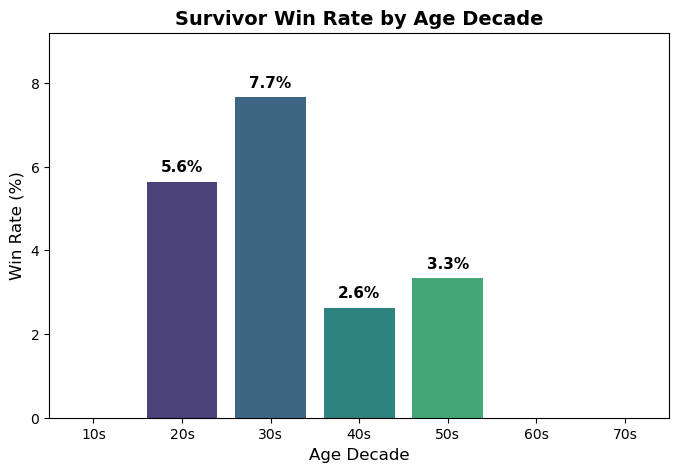

In [345]:
# 1. Bucket all players' ages into decades using floor division
df['age_decade'] = (df['age'] // 10) * 10

# 2. Calculate the win rate percentage for each age decade
# (Percentage of players in that specific decade who achieved place == 1)
win_rates = df.groupby('age_decade')['place'].apply(lambda x: (x == 1).mean() * 100).sort_index()

# 3. Plot the results
plt.figure(figsize=(8, 5))
ax = sns.barplot(
    x=win_rates.index, 
    y=win_rates.values, 
    hue=win_rates.index,
    palette="viridis",
    legend=False
)

# Format the x-axis labels to read decade (e.g., "20s", "30s")
ax.set_xticks(range(len(win_rates.index)))
ax.set_xticklabels([f"{int(decade)}s" for decade in win_rates.index])

# Add titles and labels
plt.title("Survivor Win Rate by Age Decade", fontsize=14, fontweight="bold")
plt.xlabel("Age Decade", fontsize=12)
plt.ylabel("Win Rate (%)", fontsize=12)

# Set y-axis limit to give room for the percentage labels
plt.ylim(0, max(win_rates.values) * 1.2)

# Add the exact percentage value on top of each bar
for p in ax.patches:
    height = p.get_height()
    # Handle potential NaN or empty bars gracefully
    if pd.isna(height) or height == 0:
        continue
    ax.annotate(
        f"{height:.1f}%", 
        (p.get_x() + p.get_width() / 2., height), 
        ha='center', va='bottom', 
        xytext=(0, 5), 
        textcoords='offset points',
        fontsize=11, fontweight='bold'
    )

# Show graph
plt.show()

In [346]:
# Filter for winners (place == 1) who are in their 60s (age 60 through 69)
winners_in_60s = df[(df['place'] == 1) & (df['age'] >= 60) & (df['age'] < 70)]

# Display the castaway IDs and their corresponding ages
print(winners_in_60s[['castaway_id', 'age']])

Empty DataFrame
Columns: [castaway_id, age]
Index: []


#### BIPOC and placement

In [347]:
fig = px.scatter(
    df,
    x="bipoc",
    y="place",
    hover_data=["full_name", "season"], # show name and season on hover
    title="Finishing Place by Player BIPOC Status",
    labels={"place": "Finishing Place", "bipoc": "BIPOC Status"}
)

# Force the x-axis to only display ticks at 0 and 1 and label
fig.update_xaxes(
    tickmode="array",
    tickvals=[0, 1],
    ticktext=["White (0)", "BIPOC (1)"], 
    range=[-0.4, 1.4]
)

fig.show()

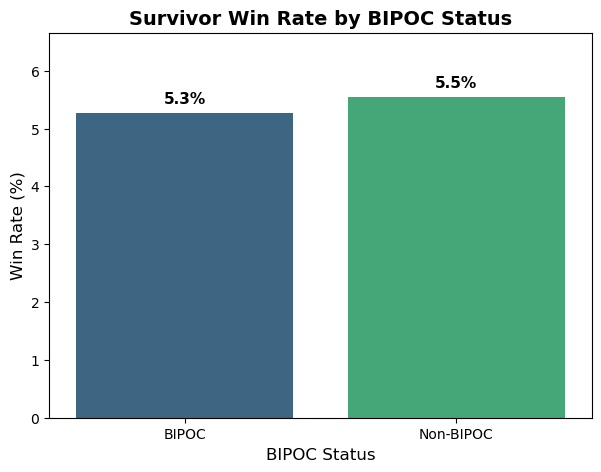

In [348]:
# 1. Map the bipoc numerical values to clean text labels
df['bipoc_label'] = df['bipoc'].map({0: 'Non-BIPOC', 1: 'BIPOC'})

# 2. Calculate the win rate percentage for each category 
# (Percentage of players in that group who achieved place == 1)
win_rates = df.groupby('bipoc_label')['place'].apply(lambda x: (x == 1).mean() * 100)

# 3. Plot the results
plt.figure(figsize=(7, 5))
ax = sns.barplot(
    x=win_rates.index, 
    y=win_rates.values, 
    hue=win_rates.index,
    palette="viridis",
    legend=False
)

# Add titles and labels
plt.title("Survivor Win Rate by BIPOC Status", fontsize=14, fontweight="bold")
plt.xlabel("BIPOC Status", fontsize=12)
plt.ylabel("Win Rate (%)", fontsize=12)

# Set y-axis limit to give room for the percentage labels
plt.ylim(0, max(win_rates.values) * 1.2)

# Add the exact percentage value on top of each bar
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f"{height:.1f}%", 
        (p.get_x() + p.get_width() / 2., height), 
        ha='center', va='bottom', 
        xytext=(0, 5), 
        textcoords='offset points',
        fontsize=11, fontweight='bold'
    )

# Show graph
plt.show()

#### Region and placement

In [349]:
fig = px.scatter(
    df,
    x="region",
    y="place",
    hover_data=["full_name", "season"], # show name and season on hover
    title="Finishing Place by Region",
    labels={"place": "Finishing Place", "region": "Region"}
)

fig.show()

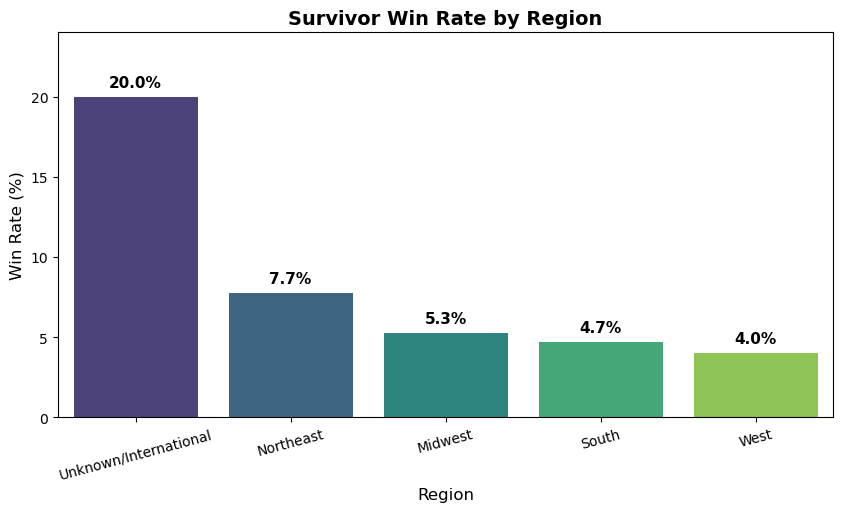

In [350]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Calculate the win rate percentage for each region
# (Percentage of players in that specific region who achieved place == 1)
win_rates = df.groupby('region')['place'].apply(lambda x: (x == 1).mean() * 100).sort_values(ascending=False)

# 2. Plot the results
plt.figure(figsize=(10, 5))
ax = sns.barplot(
    x=win_rates.index, 
    y=win_rates.values, 
    hue=win_rates.index,
    palette="viridis",
    legend=False
)

# Add titles and labels
plt.title("Survivor Win Rate by Region", fontsize=14, fontweight="bold")
plt.xlabel("Region", fontsize=12)
plt.ylabel("Win Rate (%)", fontsize=12)

# Rotate x-axis labels in case region names are long
plt.xticks(rotation=15)

# Set y-axis limit to give room for the percentage labels
plt.ylim(0, max(win_rates.values) * 1.2)

# Add the exact percentage value on top of each bar
for p in ax.patches:
    height = p.get_height()
    if pd.isna(height) or height == 0:
        continue
    ax.annotate(
        f"{height:.1f}%", 
        (p.get_x() + p.get_width() / 2., height), 
        ha='center', va='bottom', 
        xytext=(0, 5), 
        textcoords='offset points',
        fontsize=11, fontweight='bold'
    )

# Show graph
plt.show()

In [351]:
# Convert all categories into 0/1 dummy columns
encoded_df = pd.get_dummies(df[['region', 'place']], columns=['region'], drop_first=True)

# Now check correlation against 'place'
correlation_matrix = encoded_df.corr()
print(correlation_matrix['place'].sort_values(ascending=False))

place                           1.000000
region_West                     0.056369
region_South                    0.017276
region_Northeast               -0.034939
region_Unknown/International   -0.039904
Name: place, dtype: float64


#### Gender and placement

In [352]:
fig = px.scatter(
    df,
    x="gender",
    y="place",
    hover_data=["full_name", "season"], # show name and season on hover
    title="Finishing Place by Gender",
    labels={"place": "Finishing Place", "gender": "Gender"}
)

fig.update_xaxes(
    tickmode="array",
    tickvals=[0, 1],
    ticktext=["Male", "Female"], 
    range=[-0.4, 1.4]
)

fig.show()

/var/folders/jm/sgn_4jkd7k79zcv0m0w6hcvh0000gn/T/ipykernel_1184/1030515937.py:19: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



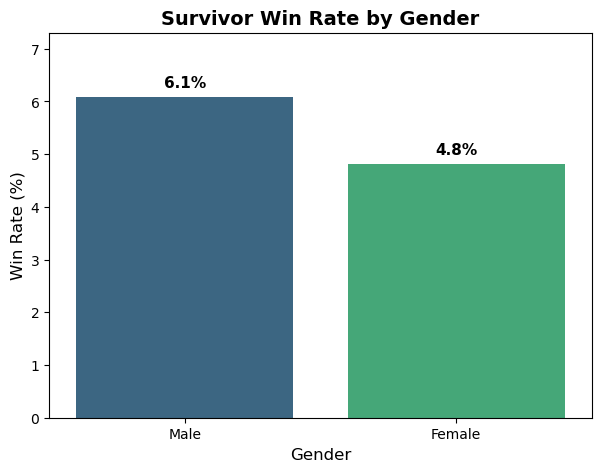

In [353]:
# Calculate the win rate percentage for each category 
# (Percentage of players in that group who achieved place == 1)
win_rates = df.groupby('gender')['place'].apply(lambda x: (x == 1).mean() * 100)

# Plot the results
plt.figure(figsize=(7, 5))
ax = sns.barplot(
    x=win_rates.index, 
    y=win_rates.values, 
    hue=win_rates.index,
    palette="viridis",
    legend=False
)

# Add titles and labels
plt.title("Survivor Win Rate by Gender", fontsize=14, fontweight="bold")
plt.xlabel("Gender", fontsize=12)
plt.ylabel("Win Rate (%)", fontsize=12)
ax.set_xticklabels(["Male", "Female"])

# Set y-axis limit to give room for the percentage labels
plt.ylim(0, max(win_rates.values) * 1.2)

# Add the exact percentage value on top of each bar
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f"{height:.1f}%", 
        (p.get_x() + p.get_width() / 2., height), 
        ha='center', va='bottom', 
        xytext=(0, 5), 
        textcoords='offset points',
        fontsize=11, fontweight='bold'
    )

# Show graph
plt.show()

#### Save cleaned dataset for modeling

In [354]:
df.to_csv("../data/survivor_clean.csv", index=False)
print("DataFrame saved")

DataFrame saved


In [355]:
df[['rel_age', 'gender', 'bipoc', 'occupation_group', 'region', 'new_era']].head()

,rel_age,gender,bipoc,occupation_group,region,new_era
0,8.083333,1,0.0,Academic,West,1
1,-7.916667,0,1.0,Corporate,Northeast,1
2,-7.916667,1,1.0,Creative,South,1
3,-7.916667,0,1.0,Corporate,South,1
4,15.083333,0,0.0,Creative,West,1
